In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import generate_initial_dataframe

In [3]:
df_init = generate_initial_dataframe(year=2025, seed=42)
df_init.to_csv('data/initial.csv', index=False)
df_init.head()

,Date,Product_A,Product_B,Product_C,Product_D
0,2025-01-01,88,34,40,21
1,2025-02-01,78,30,55,40
2,2025-03-01,64,79,23,13
3,2025-04-01,92,51,52,42
4,2025-05-01,57,46,40,41


In [4]:
df = df_init.copy()
df['Total_Sales'] = df[['Product_A','Product_B','Product_C','Product_D']].sum(axis=1)
df['Average_Sales'] = df[['Product_A','Product_B','Product_C','Product_D']].mean(axis=1)
df = df.sort_values('Date').reset_index(drop=True)
df['Month_over_Month_Growth'] = df['Total_Sales'].pct_change().fillna(0)*100
df['Month'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.month.map(lambda m: 'Q1' if m<=3 else ('Q2' if m<=6 else ('Q3' if m<=9 else 'Q4')))
df['Max_Sales_Product'] = df[['Product_A','Product_B','Product_C','Product_D']].idxmax(axis=1)
df['Min_Sales_Product'] = df[['Product_A','Product_B','Product_C','Product_D']].idxmin(axis=1)
df.to_csv('data/final.csv', index=False)
df.head()

,Date,Product_A,Product_B,Product_C,Product_D,Total_Sales,Average_Sales,Month_over_Month_Growth,Month,Quarter,Max_Sales_Product,Min_Sales_Product
0,2025-01-01,88,34,40,21,183,45.75,0.000000,Jan,Q1,Product_A,Product_D
1,2025-02-01,78,30,55,40,203,50.75,10.928962,Feb,Q1,Product_A,Product_B
2,2025-03-01,64,79,23,13,179,44.75,-11.822660,Mar,Q1,Product_B,Product_D
3,2025-04-01,92,51,52,42,237,59.25,32.402235,Apr,Q2,Product_A,Product_D
4,2025-05-01,57,46,40,41,184,46.00,-22.362869,May,Q2,Product_A,Product_C


In [8]:
# Pivot: average per quarter for each product
pivot_avg = df.pivot_table(values=['Product_A','Product_B','Product_C','Product_D'],
                           index='Quarter', aggfunc='mean')

# Total sales per quarter (sum across months then across products)
quarter_totals = df.groupby('Quarter')['Total_Sales'].sum().sort_index()

pivot_total = df.pivot_table(values=['Total_Sales'], index='Quarter', aggfunc='sum')

output = {
    'final_dataframe': df,
    'pivot_avg': pivot_avg,
    'quarter_totals': quarter_totals
}


pivot_avg.to_csv('data/output_pivot_avg_per_quarter.csv')
pivot_total.to_csv('data/output_pivot_total_per_quarter.csv')

df.to_csv('data/output.csv', index=False)
df.head()


,Date,Product_A,Product_B,Product_C,Product_D,Total_Sales,Average_Sales,Month_over_Month_Growth,Month,Quarter,Max_Sales_Product,Min_Sales_Product
0,2025-01-01,88,34,40,21,183,45.75,0.000000,Jan,Q1,Product_A,Product_D
1,2025-02-01,78,30,55,40,203,50.75,10.928962,Feb,Q1,Product_A,Product_B
2,2025-03-01,64,79,23,13,179,44.75,-11.822660,Mar,Q1,Product_B,Product_D
3,2025-04-01,92,51,52,42,237,59.25,32.402235,Apr,Q2,Product_A,Product_D
4,2025-05-01,57,46,40,41,184,46.00,-22.362869,May,Q2,Product_A,Product_C


In [6]:
# Best month (by Total_Sales)
best_month_row = df.loc[df['Total_Sales'].idxmax()]
best_month = best_month_row['Month']  # أو best_month_row['Date'] للحصول على التاريخ الكامل

# Best product (highest cumulative annual sales)
total_per_product = df[['Product_A','Product_B','Product_C','Product_D']].sum()
best_product = total_per_product.idxmax()
best_product_value = total_per_product.max()

# Best quarter (highest total sales)
best_quarter = quarter_totals.idxmax()
best_quarter_value = quarter_totals.max()

print("Best month:", best_month, best_month_row['Total_Sales'])
print("Best product:", best_product, best_product_value)
print("Best quarter:", best_quarter, best_quarter_value)


Best month: Apr 237
Best product: Product_A 870
Best quarter: Q3 607


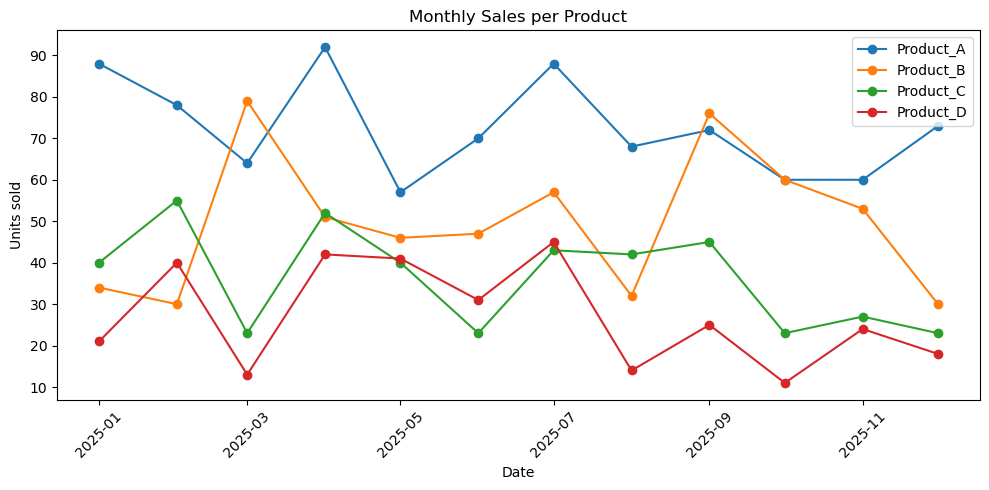

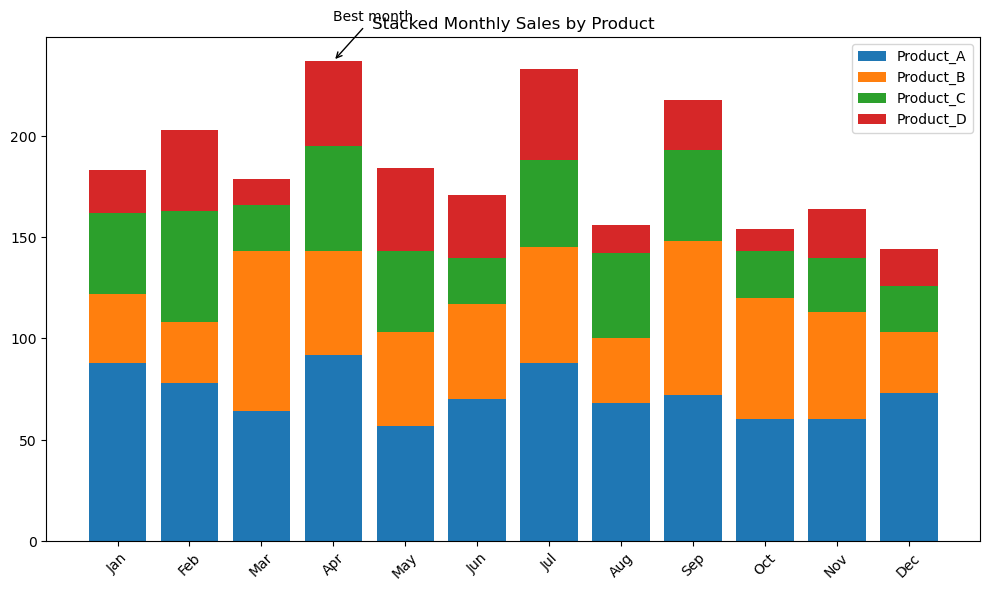

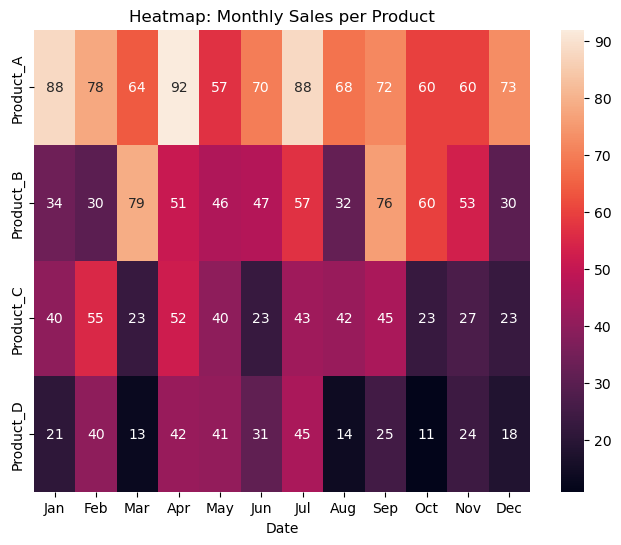

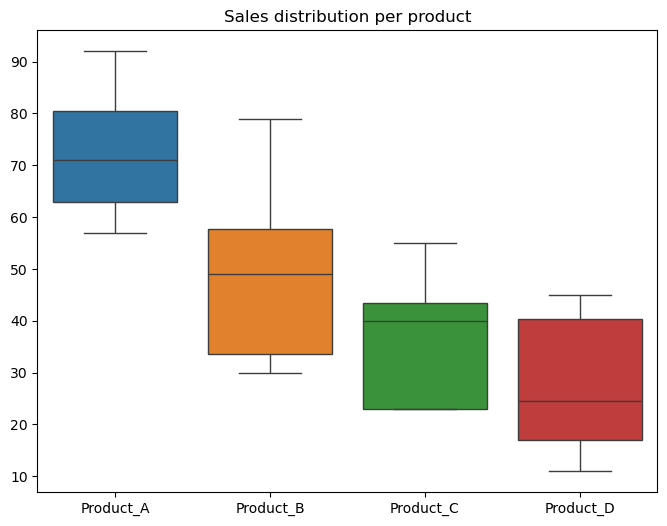

In [7]:

# 1. Line chart for each product across months
plt.figure(figsize=(10,5))
for col in ['Product_A','Product_B','Product_C','Product_D']:
    plt.plot(df['Date'], df[col], marker='o', label=col)
plt.title('Monthly Sales per Product')
plt.xlabel('Date')
plt.ylabel('Units sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/line_products.png')
plt.show()

# 2. Stacked bar chart of total monthly sales by product
plt.figure(figsize=(10,6))
bottom = None
months = df['Date'].dt.strftime('%b')
pA = df['Product_A']
pB = df['Product_B']
pC = df['Product_C']
pD = df['Product_D']
plt.bar(months, pA, label='Product_A')
plt.bar(months, pB, bottom=pA, label='Product_B')
plt.bar(months, pC, bottom=pA+pB, label='Product_C')
plt.bar(months, pD, bottom=pA+pB+pC, label='Product_D')
plt.xticks(rotation=45)
plt.legend()
plt.title('Stacked Monthly Sales by Product')

# annotate best month
best_idx = df['Total_Sales'].idxmax()
plt.annotate('Best month', xy=(best_idx, df.loc[best_idx,'Total_Sales']),
             xytext=(best_idx, df['Total_Sales'].max()+20),
             arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.savefig('figures/stacked_monthly.png')
plt.show()

# 3. Heatmap monthly sales of each product (month vs product)
heat_df = df.set_index(df['Date'].dt.strftime('%b'))[['Product_A','Product_B','Product_C','Product_D']]
plt.figure(figsize=(8,6))
sns.heatmap(heat_df.T, annot=True, fmt='g')  # products as rows
plt.title('Heatmap: Monthly Sales per Product')
plt.savefig('figures/heatmap_products.png')
plt.show()

# 4. Boxplot distribution of sales per product
plt.figure(figsize=(8,6))
sns.boxplot(data=df[['Product_A','Product_B','Product_C','Product_D']])
plt.title('Sales distribution per product')
plt.savefig('figures/boxplot_products.png')
plt.show()
